# Numerical RG grid test

This notebook builds the `LatticeGrid` from `b_min`, `b_max`, `n_nodes`, and `bstar_func`, then shows the derived arrays and a few simple plots.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

import julia
from julia import Main

In [2]:
cwd = Path.cwd()
if (cwd / "numerical_rg.jl").exists():
    rg_dir = cwd
else:
    rg_dir = cwd / "Numerical RG"

Main.include(str(rg_dir / "numerical_rg.jl"))

<PyCall.jlwrap solve_stepwise_rg>

In [8]:
# Edit these values.
n_nodes = 1000
b_min = 5e-4
b_max = 3*10
bstar_scale = 1.122918

Main.n_nodes = int(n_nodes)
Main.b_min = float(b_min)
Main.b_max = float(b_max)
Main.bstar_scale = float(bstar_scale)

Main.eval("""
bstar_func(b) = b / sqrt(1 + (b / bstar_scale)^2)

grid = build_lattice_grid(
    n_nodes = n_nodes,
    b_min = b_min,
    b_max = b_max,
    bstar_func = bstar_func,
)
""")

<PyCall.jlwrap LatticeGrid(1000, 0.0005, 30.0, 0.011013112954158397, [3.4011973816621555, 3.3901842687079973, 3.3791711557538386, 3.3681580427996805, 3.357144929845522, 3.3461318168913636, 3.335118703937205, 3.324105590983047, 3.313092478028888, 3.30207936507473, 3.2910662521205714, 3.280053139166413, 3.2690400262122545, 3.2580269132580963, 3.2470138003039377, 3.2360006873497795, 3.2249875743956213, 3.2139744614414627, 3.2029613484873045, 3.191948235533146, 3.1809351225789877, 3.169922009624829, 3.158908896670671, 3.1478957837165122, 3.136882670762354, 3.1258695578081954, 3.1148564448540372, 3.1038433318998786, 3.0928302189457204, 3.081817105991562, 3.0708039930374036, 3.0597908800832454, 3.0487777671290868, 3.0377646541749286, 3.02675154122077, 3.0157384282666118, 3.004725315312453, 2.993712202358295, 2.9826990894041363, 2.971685976449978, 2.9606728634958195, 2.9496597505416613, 2.9386466375875027, 2.9276335246333445, 2.916620411679186, 2.9056072987250277, 2.894594185770869, 2.8835810

In [11]:
node = np.arange(1, int(Main.eval("grid.n_nodes")) + 1)
ell_grid = np.array(Main.eval("collect(grid.ell_grid)"), dtype=float)
b_grid = np.array(Main.eval("collect(grid.b_grid)"), dtype=float)
bstar_grid = np.array(Main.eval("collect(grid.bstar_grid)"), dtype=float)
mu_i_grid = np.array(Main.eval("collect(grid.mu_i_grid)"), dtype=float)
t_grid = np.array(Main.eval("collect(grid.t_grid)"), dtype=float)
t_node = np.log(mu_i_grid**2)

grid_df = pd.DataFrame({
    "node": node,
    "ell_grid": ell_grid,
    "b_grid": b_grid,
    "bstar_grid": bstar_grid,
    "mu_i_grid": mu_i_grid,
    "t_node": t_node,
})

display(grid_df)
print(f"number of time nodes = {len(t_grid)}")
print(mu_i_grid)

,node,ell_grid,b_grid,bstar_grid,mu_i_grid,t_node
0,1,3.401197,30.000000,1.122132,1.000701,0.001402
1,2,3.390184,29.671419,1.122115,1.000717,0.001433
2,3,3.379171,29.346437,1.122097,1.000733,0.001465
3,4,3.368158,29.025015,1.122079,1.000749,0.001497
4,5,3.357145,28.707113,1.122060,1.000766,0.001531
...,...,...,...,...,...,...
995,996,-7.556850,0.000523,0.000523,2149.051007,15.345563
996,997,-7.567863,0.000517,0.000517,2172.849551,15.367589
997,998,-7.578876,0.000511,0.000511,2196.911639,15.389616
998,999,-7.589889,0.000506,0.000506,2221.240191,15.411642


number of time nodes = 1000
[1.00070114e+00 1.00071673e+00 1.00073267e+00 1.00074896e+00
 1.00076561e+00 1.00078264e+00 1.00080004e+00 1.00081783e+00
 1.00083602e+00 1.00085461e+00 1.00087362e+00 1.00089305e+00
 1.00091291e+00 1.00093321e+00 1.00095396e+00 1.00097518e+00
 1.00099687e+00 1.00101904e+00 1.00104170e+00 1.00106487e+00
 1.00108855e+00 1.00111276e+00 1.00113751e+00 1.00116281e+00
 1.00118867e+00 1.00121511e+00 1.00124213e+00 1.00126976e+00
 1.00129800e+00 1.00132687e+00 1.00135638e+00 1.00138655e+00
 1.00141739e+00 1.00144891e+00 1.00148114e+00 1.00151408e+00
 1.00154775e+00 1.00158217e+00 1.00161736e+00 1.00165333e+00
 1.00169010e+00 1.00172769e+00 1.00176612e+00 1.00180539e+00
 1.00184554e+00 1.00188659e+00 1.00192854e+00 1.00197143e+00
 1.00201527e+00 1.00206009e+00 1.00210590e+00 1.00215273e+00
 1.00220060e+00 1.00224954e+00 1.00229956e+00 1.00235069e+00
 1.00240296e+00 1.00245639e+00 1.00251101e+00 1.00256684e+00
 1.00262391e+00 1.00268225e+00 1.00274189e+00 1.00280285e

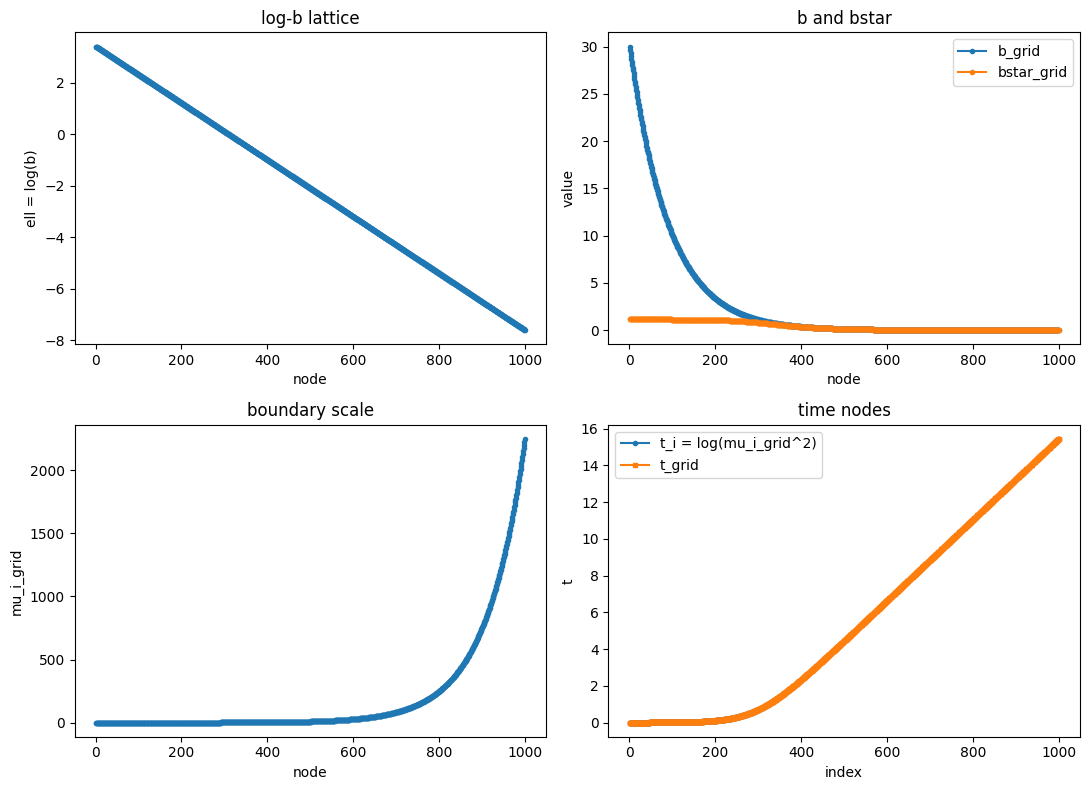

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].plot(node, ell_grid, marker="o", ms=3)
axes[0, 0].set_title("log-b lattice")
axes[0, 0].set_xlabel("node")
axes[0, 0].set_ylabel("ell = log(b)")

axes[0, 1].plot(node, b_grid, marker="o", ms=3, label="b_grid")
axes[0, 1].plot(node, bstar_grid, marker="o", ms=3, label="bstar_grid")
axes[0, 1].set_title("b and bstar")
axes[0, 1].set_xlabel("node")
axes[0, 1].set_ylabel("value")
axes[0, 1].legend()

axes[1, 0].plot(node, mu_i_grid, marker="o", ms=3)
axes[1, 0].set_title("boundary scale")
axes[1, 0].set_xlabel("node")
axes[1, 0].set_ylabel("mu_i_grid")

axes[1, 1].plot(node, t_node, marker="o", ms=3, label="t_i = log(mu_i_grid^2)")
axes[1, 1].plot(np.arange(1, len(t_grid) + 1), t_grid, marker="s", ms=3, label="t_grid")
axes[1, 1].set_title("time nodes")
axes[1, 1].set_xlabel("index")
axes[1, 1].set_ylabel("t")
axes[1, 1].legend()

plt.tight_layout()